# Companion Notebook  
## *Rethinking Gravitation: The Nexus of Geometric Back-Reaction, Twistor String Dynamics, and the Computational Topology of Spacetime*

**Driven by Dean A. Kulik**  
**Computational companion notebook**

This notebook is a runnable companion to the paper. It is designed to do four things:

1. reproduce the **scalar-tail sign problem**,  
2. derive and test the **metric-like precession route**,  
3. source the implementation coefficient from **compactness / maintenance energy**,  
4. connect **boundary shape, recursion, and waves** to the same metric branch.

This is a companion notebook, not the full paper text pasted into notebook cells. The goal is to make the paper's computational branch executable, inspectable, and easy to extend.


In [1]:
# Install dependencies if needed
# Uncomment if running in a fresh environment:
# %pip install numpy pandas matplotlib scipy sympy nbformat nbclient


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legval

# Physical constants
G = 6.67430e-11
c = 299792458.0

# Reference bodies
M_sun = 1.98847e30
R_sun = 6.957e8
M_earth = 5.9722e24
R_earth = 6.371e6

# Mercury reference orbit
a_mercury = 5.790905e10
e_mercury = 0.205630
period_mercury_days = 87.9691
arcsec_per_rad = 206264.80624709636

pd.set_option("display.precision", 8)


Matplotlib is building the font cache; this may take a moment.


## 1. High-level model map

The working chain explored in this notebook is

$$
(\mathcal B,\mathcal T,\mathcal R)
\;\to\;
E_{\mathrm{maint}}
\;\to\;
q_\Gamma
\;\to\;
(\beta_\Gamma,\gamma_\Gamma)
\;\to\;
\text{effective metric}
\;\to\;
\text{precession, lensing, clock shift}.
$$

The paper motivates gravity as an emergent geometric back-reaction rather than a primitive fourth force, and uses perihelion precession as a clean test arena for sign and magnitude logic. This notebook keeps that structure but makes the computation explicit.


## 2. Utilities

We start with a few reusable helper functions:

- compactness
  $$
  C = \frac{GM}{Rc^2},
  $$
- maintenance-derived implementation coefficient
  $$
  q_\Gamma = \chi \alpha_s \frac{GM}{Rc^2},
  $$
- weak-field observable factors
  $$
  F_{\mathrm{peri}}
  =
  1+\frac{(2\zeta-\xi)}{3}q_\Gamma,
  \qquad
  F_{\mathrm{bend}}
  =
  1+\frac{\zeta}{2}q_\Gamma.
  $$


In [3]:
def compactness(M: float, R: float) -> float:
    return G * M / (R * c**2)

def q_gamma_base(M: float, R: float, chi: float = 1.0, alpha_s: float = 0.6) -> float:
    return chi * alpha_s * compactness(M, R)

def observable_factors_from_q(q: float, xi: float = 0.2, zeta: float = 0.4):
    beta_gamma = 1 + xi * q
    gamma_gamma = 1 + zeta * q
    F_peri = 1 + ((2 * zeta - xi) / 3.0) * q
    F_bend = 1 + (zeta / 2.0) * q
    return beta_gamma, gamma_gamma, F_peri, F_bend

def mercury_gr_precession_arcsec_per_century() -> float:
    dvarpi_gr = 6 * math.pi * G * M_sun / (a_mercury * (1 - e_mercury**2) * c**2)
    dvarpi_gr_arcsec_orbit = dvarpi_gr * arcsec_per_rad
    orbits_per_century = 36525.0 / period_mercury_days
    return dvarpi_gr_arcsec_orbit * orbits_per_century

def solar_limb_gr_bending_arcsec() -> float:
    alpha_gr = 4 * G * M_sun / (R_sun * c**2)
    return alpha_gr * arcsec_per_rad


## 3. The scalar-tail proxy and the hard sign problem

The paper's first route starts from the additive scalar correction

$$
\Phi(r) = -\frac{\mu}{r} + \frac{A}{r^2}.
$$

This gives the small-correction perihelion shift

$$
\Delta\varpi \approx -\,\frac{2\pi A}{\mu a(1-e^2)}.
$$

So the sign logic is immediate:

- $A > 0 \Rightarrow$ **retrograde**
- $A < 0 \Rightarrow$ **prograde**

That is the scalar-tail sign problem.


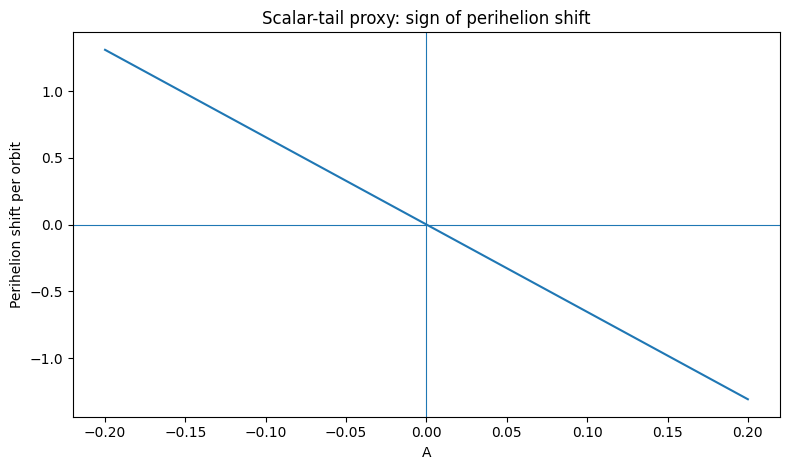

In [4]:
def delta_varpi_scalar_small(A: float, mu: float = 1.0, a: float = 1.0, e: float = 0.2) -> float:
    return -2 * math.pi * A / (mu * a * (1 - e**2))

A_vals = np.linspace(-0.2, 0.2, 401)
scalar_shifts = [delta_varpi_scalar_small(A, mu=1.0, a=1.0, e=0.2) for A in A_vals]

plt.figure(figsize=(8, 4.8))
plt.plot(A_vals, scalar_shifts)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("A")
plt.ylabel("Perihelion shift per orbit")
plt.title("Scalar-tail proxy: sign of perihelion shift")
plt.tight_layout()
plt.show()


## 4. The metric-like orbit route

The metric-like correction is modeled at orbit level by

$$
u'' + u = k + \beta u^2.
$$

Its first-order perihelion shift is

$$
\Delta\varpi \approx \frac{2\pi \beta}{a(1-e^2)}.
$$

This flips the sign logic:

- $\beta > 0 \Rightarrow$ **prograde**
- $\beta < 0 \Rightarrow$ **retrograde**

So the metric route fixes the sign logic that the scalar-tail route fails to capture.


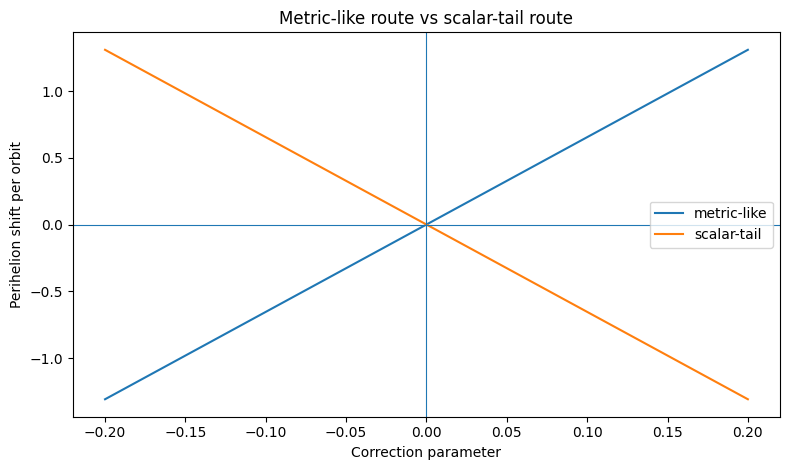

In [5]:
def delta_varpi_metric(beta: float, a: float = 1.0, e: float = 0.2) -> float:
    return 2 * math.pi * beta / (a * (1 - e**2))

beta_vals = np.linspace(-0.2, 0.2, 401)
metric_shifts = [delta_varpi_metric(beta, a=1.0, e=0.2) for beta in beta_vals]

plt.figure(figsize=(8, 4.8))
plt.plot(beta_vals, metric_shifts, label="metric-like")
plt.plot(A_vals, scalar_shifts, label="scalar-tail")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Correction parameter")
plt.ylabel("Perihelion shift per orbit")
plt.title("Metric-like route vs scalar-tail route")
plt.legend()
plt.tight_layout()
plt.show()


## 5. PPN-like effective metric

Now we use the weak-field metric ansatz

$$
ds^2
=
-\left(1-2U+2\beta_\Gamma U^2\right)c^2dt^2
+
\left(1+2\gamma_\Gamma U\right)dr^2
+
r^2 d\Omega^2,
$$

with

$$
U(r)=\frac{GM}{rc^2},
\qquad
\beta_\Gamma = 1+\xi q_\Gamma,
\qquad
\gamma_\Gamma = 1+\zeta q_\Gamma.
$$

This gives the leading observable factors:

$$
F_{\mathrm{peri}}
=
1+\frac{(2\zeta-\xi)}{3}q_\Gamma,
\qquad
F_{\mathrm{bend}}
=
1+\frac{\zeta}{2}q_\Gamma.
$$

The next question is whether a positive $q_\Gamma$ admits a sane sign region.


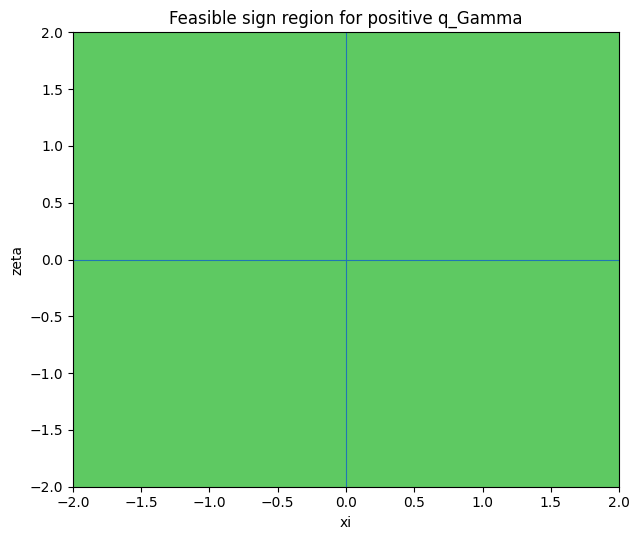

In [6]:
q = 0.1
xis = np.linspace(-2, 2, 401)
zetas = np.linspace(-2, 2, 401)
XI, ZETA = np.meshgrid(xis, zetas)

F_PERI = 1 + ((2 * ZETA - XI) / 3.0) * q
F_BEND = 1 + (ZETA / 2.0) * q
F_CLOCK2 = 0.5 - XI * q  # from delta z_Gamma = -xi q U^2

FEASIBLE = (F_PERI > 0) & (F_BEND > 0) & (F_CLOCK2 > 0)

plt.figure(figsize=(6.5, 5.5))
plt.contourf(XI, ZETA, FEASIBLE.astype(int), levels=[-0.5, 0.5, 1.5])
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("xi")
plt.ylabel("zeta")
plt.title("Feasible sign region for positive q_Gamma")
plt.tight_layout()
plt.show()


## 6. Source classes and compactness hierarchy

We now move from abstract $q_\Gamma$ to sourced $q_\Gamma$.

The first candidate source ratio is compactness:

$$
C = \frac{GM}{Rc^2}.
$$

Let's compute it for representative source classes.


In [7]:
sources = [
    ("Earth", M_earth, R_earth),
    ("Sun", M_sun, R_sun),
    ("White dwarf (0.6 Msun, 7000 km)", 0.6 * M_sun, 7.0e6),
    ("Neutron star (1.4 Msun, 12 km)", 1.4 * M_sun, 1.2e4),
]

source_rows = []
for name, M, R in sources:
    source_rows.append({
        "source": name,
        "M_kg": M,
        "R_m": R,
        "compactness_C": compactness(M, R),
    })

source_df = pd.DataFrame(source_rows)
source_df


,source,M_kg,R_m,compactness_C
0,Earth,5.97220000e+24,6371000.0,6.96131131e-10
1,Sun,1.98847000e+30,695700000.0,2.12256675e-06
2,"White dwarf (0.6 Msun, 7000 km)",1.19308200e+30,7000000.0,1.26571688e-04
3,"Neutron star (1.4 Msun, 12 km)",2.78385800e+30,12000.0,1.72278131e-01


## 7. Maintenance-energy derivation of compactness

The companion model interprets compactness as a maintenance fraction.

Start from

$$
q_\Gamma
=
\chi \frac{|E_{\mathrm{maint}}|}{M c^2},
$$

and approximate the self-maintenance scale by

$$
E_{\mathrm{maint}}
\sim
-\,\alpha_s \frac{GM^2}{R}.
$$

Then

$$
\boxed{
q_\Gamma
=
\chi \alpha_s \frac{GM}{Rc^2}.
}
$$

Two standard shape factors are:

- thin shell:
  $$
  \alpha_s = \frac{1}{2},
  $$
- uniform sphere:
  $$
  \alpha_s = \frac{3}{5}.
  $$

So compactness is not just a fitted knob; it is the first dimensionless maintenance fraction.


In [8]:
maintenance_rows = []
for _, row in source_df.iterrows():
    C = row["compactness_C"]
    maintenance_rows.append({
        "source": row["source"],
        "C": C,
        "q_shell_(chi=1)": 0.5 * C,
        "q_sphere_(chi=1)": 0.6 * C,
    })

maintenance_df = pd.DataFrame(maintenance_rows)
maintenance_df


,source,C,q_shell_(chi=1),q_sphere_(chi=1)
0,Earth,6.96131131e-10,3.48065566e-10,4.17678679e-10
1,Sun,2.12256675e-06,1.06128338e-06,1.27354005e-06
2,"White dwarf (0.6 Msun, 7000 km)",1.26571688e-04,6.32858439e-05,7.59430127e-05
3,"Neutron star (1.4 Msun, 12 km)",1.72278131e-01,8.61390653e-02,1.03366878e-01


## 8. Observable corrections from sourced compactness

Choose one feasible parameter region, for example

$$
\xi=0.2,\qquad \zeta=0.4,\qquad \chi=1,\qquad \alpha_s=0.6.
$$

Then propagate the source classes through the metric branch.


In [9]:
xi = 0.2
zeta = 0.4
chi = 1.0
alpha_s = 0.6

obs_rows = []
for _, row in source_df.iterrows():
    M = row["M_kg"]
    R = row["R_m"]
    qg = q_gamma_base(M, R, chi=chi, alpha_s=alpha_s)
    beta_gamma, gamma_gamma, F_peri, F_bend = observable_factors_from_q(qg, xi=xi, zeta=zeta)
    obs_rows.append({
        "source": row["source"],
        "q_Gamma": qg,
        "beta_Gamma": beta_gamma,
        "gamma_Gamma": gamma_gamma,
        "delta_peri_rel": F_peri - 1.0,
        "delta_bend_rel": F_bend - 1.0,
    })

obs_df = pd.DataFrame(obs_rows)
obs_df


,source,q_Gamma,beta_Gamma,gamma_Gamma,delta_peri_rel,delta_bend_rel
0,Earth,4.17678679e-10,1.00000000,1.00000000,8.35358449e-11,8.35358449e-11
1,Sun,1.27354005e-06,1.00000025,1.00000051,2.54708010e-07,2.54708010e-07
2,"White dwarf (0.6 Msun, 7000 km)",7.59430127e-05,1.00001519,1.00003038,1.51886025e-05,1.51886025e-05
3,"Neutron star (1.4 Msun, 12 km)",1.03366878e-01,1.02067338,1.04134675,2.06733757e-02,2.06733757e-02


## 9. Solar-system calibration

We now check the branch against the solar system.

For Mercury, the GR perihelion advance per orbit is

$$
\Delta\varpi_{\mathrm{GR}}
=
\frac{6\pi GM_\odot}{a(1-e^2)c^2}.
$$

For light bending at the solar limb,

$$
\hat\alpha_{\mathrm{GR}}
=
\frac{4GM_\odot}{R_\odot c^2}.
$$

The sourced metric branch modifies these multiplicatively by $F_{\mathrm{peri}}$ and $F_{\mathrm{bend}}$.


In [10]:
q_sun = q_gamma_base(M_sun, R_sun, chi=chi, alpha_s=alpha_s)
_, _, Fperi_sun, Fbend_sun = observable_factors_from_q(q_sun, xi=xi, zeta=zeta)

mercury_gr = mercury_gr_precession_arcsec_per_century()
solar_bend_gr = solar_limb_gr_bending_arcsec()

solar_calibration = pd.DataFrame([{
    "q_Gamma_sun": q_sun,
    "F_peri_sun": Fperi_sun,
    "F_bend_sun": Fbend_sun,
    "Mercury_GR_arcsec_per_century": mercury_gr,
    "extra_peri_arcsec_per_century": (Fperi_sun - 1.0) * mercury_gr,
    "solar_limb_GR_arcsec": solar_bend_gr,
    "extra_bend_arcsec": (Fbend_sun - 1.0) * solar_bend_gr,
}])

solar_calibration


,q_Gamma_sun,F_peri_sun,F_bend_sun,Mercury_GR_arcsec_per_century,extra_peri_arcsec_per_century,solar_limb_GR_arcsec,extra_bend_arcsec
0,0.00000127,1.00000025,1.00000025,42.9819755,0.00001095,1.75124328,0.00000045


For $\chi = O(1)$, the branch is naturally quiet in the solar system.

That is a useful sanity check:
it means weak-field invisibility does not need to be inserted by hand.


## 10. Boundary shape as wave content

We now add shape to the source via boundary-wave modes.

Represent the nearly spherical boundary as

$$
r(\Omega)=R\left[1+\delta(\Omega)\right],
\qquad
\delta(\Omega)=\sum_{\ell,m} a_{\ell m}Y_{\ell m}(\Omega).
$$

For a simple axisymmetric reduction:

$$
r(\theta)=R\left[1+\sum_{\ell\ge 2}a_\ell P_\ell(\cos\theta)\right].
$$

The first leading-order wave burden is

$$
W=\sum_{\ell\ge 2}\ell(\ell+1)a_\ell^2.
$$

Then the sourced coefficient becomes

$$
\boxed{
q_\Gamma
=
\chi \alpha_s \frac{GM}{Rc^2}\bigl(1+\nu W\bigr).
}
$$


In [11]:
def wave_burden_axisymmetric(mode_amplitudes):
    W = 0.0
    for ell, a in mode_amplitudes.items():
        if ell >= 2:
            W += ell * (ell + 1) * (a ** 2)
    return W

def q_gamma_with_waves(M, R, mode_amplitudes, chi=1.0, alpha_s=0.6, nu=1.0):
    q0 = q_gamma_base(M, R, chi=chi, alpha_s=alpha_s)
    W = wave_burden_axisymmetric(mode_amplitudes)
    return q0 * (1 + nu * W), q0, W

shape_packets = {
    "smooth_ell2": {2: 0.02},
    "mixed_low_modes": {2: 0.02, 3: 0.015, 4: 0.01},
    "rougher_high_modes": {2: 0.02, 4: 0.02, 8: 0.015, 12: 0.01},
}

wave_rows = []
for name, packet in shape_packets.items():
    q_total, q0, W = q_gamma_with_waves(M_sun, R_sun, packet, chi=1.0, alpha_s=0.6, nu=1.0)
    wave_rows.append({
        "shape_packet": name,
        "base_qGamma": q0,
        "wave_burden_W": W,
        "qGamma_total": q_total,
        "relative_boost": q_total / q0,
    })

wave_df = pd.DataFrame(wave_rows)
wave_df


,shape_packet,base_qGamma,wave_burden_W,qGamma_total,relative_boost
0,smooth_ell2,0.00000127,0.0024,0.00000128,1.0024
1,mixed_low_modes,0.00000127,0.0071,0.00000128,1.0071
2,rougher_high_modes,0.00000127,0.0422,0.00000133,1.0422


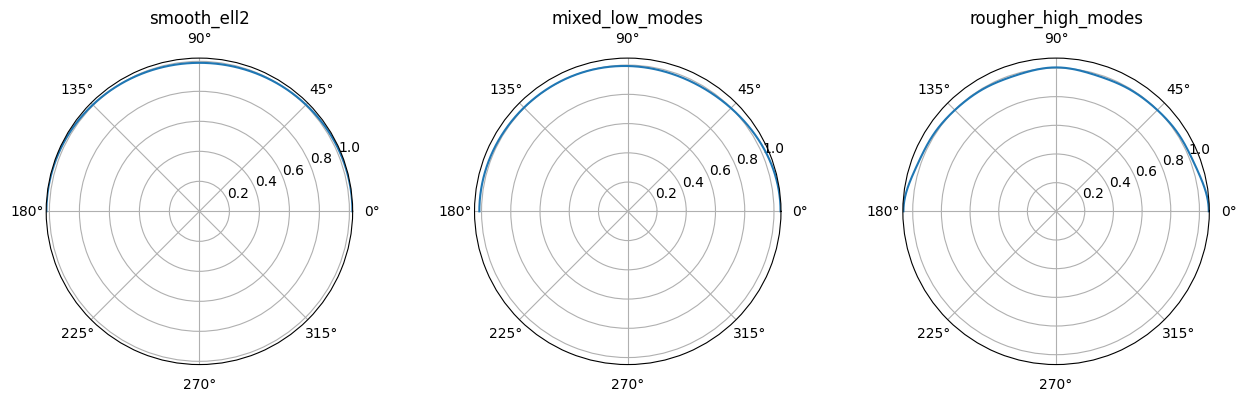

In [12]:
theta = np.linspace(0, np.pi, 800)

def radial_profile(theta_vals, modes, R=1.0):
    x = np.cos(theta_vals)
    r = np.full_like(theta_vals, R, dtype=float)
    for ell, a in modes.items():
        coeffs = np.zeros(ell + 1)
        coeffs[ell] = 1.0
        P_l = legval(x, coeffs)
        r += R * a * P_l
    return r

fig, axes = plt.subplots(1, 3, figsize=(13, 4), subplot_kw={"projection": "polar"})
for ax, (name, packet) in zip(axes, shape_packets.items()):
    rr = radial_profile(theta, packet, R=1.0)
    ax.plot(theta, rr)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 11. Deriving the wave burden from the reflection kernel

The leading $\ell(\ell+1)$ weight is not just guessed.

Take the most general rotationally invariant quadratic boundary functional

$$
E_{\mathrm{refl}}
=
\frac{\Lambda}{2}
\int_{S^2}\!\!\int_{S^2}
\delta(\Omega)\,K(\Omega\cdot\Omega')\,\delta(\Omega')\,d\Omega\,d\Omega'.
$$

Because the kernel depends only on angular separation, spherical harmonics diagonalize it:

$$
E_{\mathrm{refl}}
=
\frac{\Lambda}{2}
\sum_{\ell,m}\kappa_\ell |a_{\ell m}|^2.
$$

For a smooth local-ish kernel,

$$
\mathcal K
\approx
k_0 + k_2(-\Delta_{S^2}) + k_4(-\Delta_{S^2})^2+\cdots
$$

so

$$
\kappa_\ell
=
k_0 + k_2\ell(\ell+1)+k_4[\ell(\ell+1)]^2+\cdots
$$

and the first nontrivial angular penalty is exactly $\ell(\ell+1)$.


In [13]:
def kappa_l(ell, k0=0.0, k2=1.0, k4=0.0):
    x = ell * (ell + 1)
    return k0 + k2 * x + k4 * x * x

ells = np.arange(0, 21)
kernel_df = pd.DataFrame({
    "ell": ells,
    "laplacian_eigenvalue": ells * (ells + 1),
    "kappa_leading": [kappa_l(l, k0=0.0, k2=1.0, k4=0.0) for l in ells],
    "kappa_with_k4": [kappa_l(l, k0=0.0, k2=1.0, k4=0.02) for l in ells],
})

kernel_df.head(10)


,ell,laplacian_eigenvalue,kappa_leading,kappa_with_k4
0,0,0,0.0,0.00
1,1,2,2.0,2.08
2,2,6,6.0,6.72
3,3,12,12.0,14.88
4,4,20,20.0,28.00
5,5,30,30.0,48.00
6,6,42,42.0,77.28
7,7,56,56.0,118.72
8,8,72,72.0,175.68
9,9,90,90.0,252.00


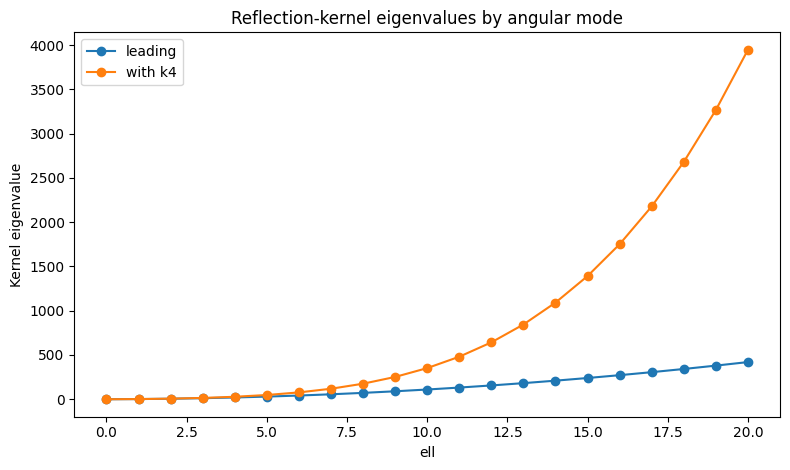

In [14]:
plt.figure(figsize=(8, 4.8))
plt.plot(kernel_df["ell"], kernel_df["kappa_leading"], "o-", label="leading")
plt.plot(kernel_df["ell"], kernel_df["kappa_with_k4"], "o-", label="with k4")
plt.xlabel("ell")
plt.ylabel("Kernel eigenvalue")
plt.title("Reflection-kernel eigenvalues by angular mode")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Recursion as gradient descent on reflection energy

Recursion becomes sharp if we update by gradient descent on $E_{\mathrm{refl}}$:

$$
a_{\ell m}^{(n+1)}
=
a_{\ell m}^{(n)}
-
\eta\frac{\partial E_{\mathrm{refl}}}{\partial \overline{a_{\ell m}}}.
$$

Since

$$
E_{\mathrm{refl}}
=
\frac{\Lambda}{2}
\sum_{\ell,m}\kappa_\ell |a_{\ell m}|^2,
$$

we get

$$
\boxed{
a_{\ell m}^{(n+1)}
=
(1-\eta\Lambda\kappa_\ell)a_{\ell m}^{(n)}.
}
$$

So high-\(\ell\) roughness damps fastest.


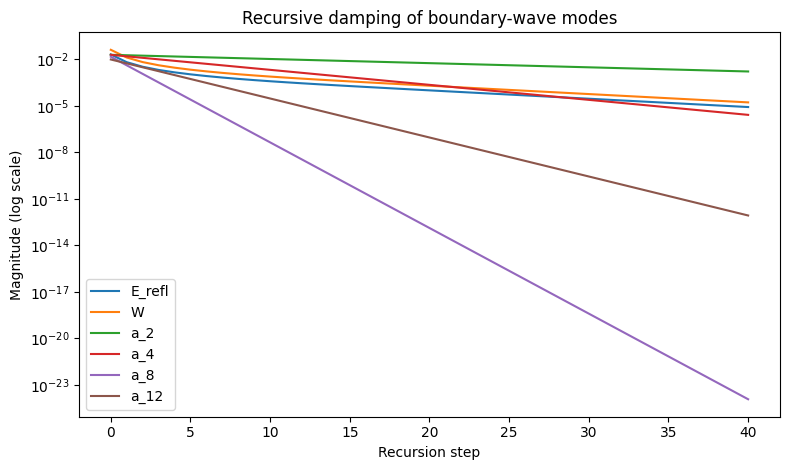

In [15]:
def recurse_modes(mode_amplitudes, eta=0.01, Lambda=1.0, k0=0.0, k2=1.0, k4=0.0, steps=40):
    current = {ell: float(a) for ell, a in mode_amplitudes.items()}
    rows = []
    for n in range(steps + 1):
        W = sum(ell * (ell + 1) * (a ** 2) for ell, a in current.items() if ell >= 2)
        E = 0.5 * Lambda * sum(kappa_l(ell, k0=k0, k2=k2, k4=k4) * (a ** 2)
                               for ell, a in current.items())
        row = {"step": n, "W": W, "E_refl": E}
        for ell, a in current.items():
            row[f"a_{ell}"] = a
        rows.append(row)

        updated = {}
        for ell, a in current.items():
            factor = 1 - eta * Lambda * kappa_l(ell, k0=k0, k2=k2, k4=k4)
            updated[ell] = factor * a
        current = updated
    return pd.DataFrame(rows)

hist = recurse_modes(shape_packets["rougher_high_modes"], eta=0.01, Lambda=1.0, steps=40)

plt.figure(figsize=(8, 4.8))
plt.semilogy(hist["step"], hist["E_refl"], label="E_refl")
plt.semilogy(hist["step"], hist["W"], label="W")
for col in [c for c in hist.columns if c.startswith("a_")]:
    plt.semilogy(hist["step"], np.abs(hist[col]), label=col)
plt.xlabel("Recursion step")
plt.ylabel("Magnitude (log scale)")
plt.title("Recursive damping of boundary-wave modes")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Compactness sets how loud the same shape becomes

The same shape packet has a tiny absolute effect for a Sun-like source and a much larger one for a neutron-star-like source, because compactness sets the base scale.


In [16]:
M_ns = 1.4 * M_sun
R_ns = 1.2e4

compare_rows = []
for source_name, M, R in [("Sun-like", M_sun, R_sun), ("NS-like", M_ns, R_ns)]:
    q_base = q_gamma_with_waves(M, R, {}, chi=1.0, alpha_s=0.6, nu=1.0)[0]
    q_rough = q_gamma_with_waves(M, R, shape_packets["rougher_high_modes"], chi=1.0, alpha_s=0.6, nu=1.0)[0]
    W_relaxed = float(hist.loc[len(hist) - 1, "W"])
    q_relaxed = q_base * (1 + W_relaxed)
    compare_rows.append({
        "source": source_name,
        "q_base": q_base,
        "q_rough": q_rough,
        "q_relaxed": q_relaxed,
        "rough_boost_factor": q_rough / q_base,
        "relaxed_boost_factor": q_relaxed / q_base,
    })

compare_df = pd.DataFrame(compare_rows)
compare_df


,source,q_base,q_rough,q_relaxed,rough_boost_factor,relaxed_boost_factor
0,Sun-like,0.00000127,0.00000133,0.00000127,1.0422,1.000017
1,NS-like,0.10336688,0.10772896,0.10336864,1.0422,1.000017


## 14. Summary table

This final table collects the notebook's key branch logic.


In [17]:
summary_df = pd.DataFrame([
    {
        "branch_element": "Scalar-tail route",
        "role": "First weak-field proxy",
        "result": "Wrong sign for positive coupling"
    },
    {
        "branch_element": "Metric-like route",
        "role": "Correct sign structure",
        "result": "Selected branch"
    },
    {
        "branch_element": "Compactness C = GM/(Rc^2)",
        "role": "Natural dimensionless source ratio",
        "result": "Weak-field quiet, strong-field loud"
    },
    {
        "branch_element": "Maintenance-energy law",
        "role": "Derives compactness source",
        "result": "q_Gamma = chi alpha_s GM/(Rc^2)"
    },
    {
        "branch_element": "Boundary-wave burden",
        "role": "Shape correction",
        "result": "W = sum l(l+1)|a_lm|^2"
    },
    {
        "branch_element": "Recursive damping",
        "role": "Stability attractor",
        "result": "High-l modes damp fastest"
    },
])

summary_df


,branch_element,role,result
0,Scalar-tail route,First weak-field proxy,Wrong sign for positive coupling
1,Metric-like route,Correct sign structure,Selected branch
2,Compactness C = GM/(Rc^2),Natural dimensionless source ratio,"Weak-field quiet, strong-field loud"
3,Maintenance-energy law,Derives compactness source,q_Gamma = chi alpha_s GM/(Rc^2)
4,Boundary-wave burden,Shape correction,W = sum l(l+1)|a_lm|^2
5,Recursive damping,Stability attractor,High-l modes damp fastest


## 15. Final companion compression

The current executable chain is

$$
(\mathcal B,\mathcal T,\mathcal R)
\to
E_{\mathrm{maint}}
\to
q_\Gamma
\to
(\beta_\Gamma,\gamma_\Gamma)
\to
\text{effective metric}
\to
\text{precession, lensing, clock shift},
$$

with shape entering through

$$
E_{\mathrm{refl}}
=
\frac{\Lambda}{2}\sum_{\ell,m}\kappa_\ell |a_{\ell m}|^2,
\qquad
\kappa_\ell
=
k_0+k_2\ell(\ell+1)+\cdots
$$

and recursive relaxation

$$
a_{\ell m}^{(n+1)}
=
(1-\eta\Lambda\kappa_\ell)a_{\ell m}^{(n)}.
$$

The next boundary after this notebook is no longer a sign or regime issue.  
It is the derivation of the physical kernel coefficients $k_0,k_2,k_4,\dots$ from a more concrete reflection law.
